# 🛒 Amazon Shopping Dataset — EDA & Data Cleaning
**Assignment 1 | Basic Data Exploration and Cleaning using Pandas**

---
### Dataset
Combined Amazon product listings across 9 categories:
- Audio/Video, Camera, Car Accessories, Laptop, Men's Clothing, Men's Shoes, Mobile, Movies, Toys

**Total Records (before cleaning):** ~1,00,678

---
## Step 0 — Combine All Category Files into One Dataset

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')


In [57]:
#  File Paths 
files = {
    'audio_video'    : 'amazon_audio_video.csv',
    'camera'         : 'amazon_camra.csv',
    'car_accessories': 'amazon_car_accessories.csv',
    'laptop'         : 'amazon_laptop.csv',
    'men_clothing'   : 'amazon_men.csv',
    'men_shoes'      : 'amazon_men_shoe.csv',
    'mobile'         : 'amazon_mobile.csv',
    'movies'         : 'amazon_movies.csv',
    'toys'           : 'amazon_toys_1.csv',
}

# Standardised column names we want to keep
KEEP = ['product_description', 'price', 'real_price',
        'num_reviews', 'free_days', 'shipment',
        'delivery_date', 'sells_past_month', 'category']

dfs = []
for cat, path in files.items():
    df = pd.read_csv(path, encoding='latin1', on_bad_lines='skip')

    # Drop completely empty columns
    df = df.dropna(axis=1, how='all')

    # Drop unnamed/garbage columns
    df = df.loc[:, ~df.columns.str.lower().str.strip().str.startswith('unnamed')]

    # Clean column names
    df.columns = (df.columns
                    .str.strip()
                    .str.lower()
                    .str.replace(r'\s+', '_', regex=True)
                    .str.replace(r'[()]', '', regex=True))

    df['category'] = cat

    # Rename to standard names
    renames = {}
    for c in df.columns:
        if 'product' in c or 'production' in c: renames[c] = 'product_description'
        elif c.startswith('price'):              renames[c] = 'price'
        elif 'real_price' in c:                  renames[c] = 'real_price'
        elif 'number_of' in c and 'review' in c: renames[c] = 'num_reviews'
        elif 'free_day' in c:                    renames[c] = 'free_days'
        elif 'sell' in c and 'month' in c:       renames[c] = 'sells_past_month'
    df.rename(columns=renames, inplace=True)

    # Keep only common columns that exist in this file
    keep = [c for c in KEEP if c in df.columns]
    df = df[keep]
    dfs.append(df)
    print(f"  {cat:20s} → {df.shape[0]:6,} rows")

combined = pd.concat(dfs, ignore_index=True)
print(f"\n Combined dataset: {combined.shape[0]:,} rows × {combined.shape[1]} columns")

  audio_video          →  2,760 rows
  camera               → 11,965 rows
  car_accessories      →  9,571 rows
  laptop               →  2,306 rows
  men_clothing         → 23,953 rows
  men_shoes            → 23,744 rows
  mobile               →  6,974 rows
  movies               →  8,002 rows
  toys                 → 11,403 rows

 Combined dataset: 100,678 rows × 9 columns


---
## Step 1 — Load & First Look at the Data

In [54]:

combined.to_csv('combined_dataset.csv', index=False)
df = pd.read_csv('combined_dataset.csv')
print(f"Dataset loaded — Shape: {df.shape}")

Dataset loaded — Shape: (100678, 9)


In [53]:
#  First 5 rows 
df.head()

,product_description,price,real_price,num_reviews,free_days,shipment,delivery_date,category,sells_past_month,price_difference,discount_pct,popularity_score,price_tier,has_discount
0,"Upgraded, Anker Soundcore Bluetooth Speaker wi...",27.0,29.99,82773.0,90 days FREE. Terms apply.,Ships to Bangladesh,"Thu, Jun 15",audio_video,Unknown,2.99,9.97,11.3239,Mid-Range,True
1,Twelve South AirFly Pro Bluetooth Wireless Aud...,54.0,33.48,5121.0,90 days FREE. Terms apply.,Ships to Bangladesh,"Thu, Jun 15",audio_video,Unknown,-20.52,0.00,8.5413,Mid-Range,False
2,iOttie Easy One Touch 5 Dashboard & Windshield...,24.0,29.98,126957.0,90 days FREE. Terms apply.,Ships to Bangladesh,"Thu, Jun 15",audio_video,Unknown,5.98,19.95,11.7516,Budget,True
3,"INIU Wireless Charger, 15W Fast Wireless Charg...",15.0,110.95,18837.0,90 days FREE. Terms apply.,Ships to Bangladesh,"Fri, Jun 16",audio_video,Unknown,95.95,86.48,9.8436,Budget,True
4,JBL Flip 4 Waterproof Portable Bluetooth Speak...,78.0,149.99,13141.0,90 days FREE. Terms apply.,Ships to Bangladesh,"Thu, Jun 15",audio_video,Unknown,71.99,48.00,9.4836,Mid-Range,True


In [55]:
df

,product_description,price,real_price,num_reviews,free_days,shipment,delivery_date,category,sells_past_month
0,"Upgraded, Anker Soundcore Bluetooth Speaker wi...",27,29.99,"82,773",90 days FREE. Terms apply.,Ships to Bangladesh,"Thu, Jun 15",audio_video,NaN
1,Twelve South AirFly Pro Bluetooth Wireless Aud...,54,33.48,"5,121",90 days FREE. Terms apply.,Ships to Bangladesh,"Thu, Jun 15",audio_video,NaN
2,iOttie Easy One Touch 5 Dashboard & Windshield...,24,29.98,"126,957",90 days FREE. Terms apply.,Ships to Bangladesh,"Thu, Jun 15",audio_video,NaN
3,"INIU Wireless Charger, 15W Fast Wireless Charg...",15,110.95,"18,837",90 days FREE. Terms apply.,Ships to Bangladesh,"Fri, Jun 16",audio_video,NaN
4,JBL Flip 4 Waterproof Portable Bluetooth Speak...,78,149.99,"13,141",90 days FREE. Terms apply.,Ships to Bangladesh,"Thu, Jun 15",audio_video,NaN
...,...,...,...,...,...,...,...,...,...
100673,Papo - Hand-Painted - Figurine - Marine Life -...,11,NaN,"1,094",90 days FREE. Terms apply.,Ships to Bangladesh,"Tue, Jun 20",toys,100+ bought in past week
100674,Green Toys Farm Playset. CB2,26,NaN,78,90 days FREE. Terms apply.,Ships to Bangladesh,"Tue, Jun 20",toys,100+ bought in past week
100675,"Teenage Mutant Ninja Turtles 5"" Sewer Shredder...",10,NaN,78,90 days FREE. Terms apply.,Ships to Bangladesh,"Tue, Jun 20",toys,100+ bought in past week
100676,"Schleich Wild Life, Wild Animal Toys for Kids,...",42,NaN,78,90 days FREE. Terms apply.,Ships to Bangladesh,"Tue, Jun 20",toys,100+ bought in past week


In [52]:
#  Last 5 rows 

df.tail()

,product_description,price,real_price,num_reviews,free_days,shipment,delivery_date,category,sells_past_month,price_difference,discount_pct,popularity_score,price_tier,has_discount
75079,Megahouse Chokorin Mascot Shaman King,7.0,7.0,172.0,90 days FREE. Terms apply.,Ships to Bangladesh,"Tue, Jun 20",toys,100+ bought in past week,0.0,0.0,5.1533,Budget,False
75080,Teenage Mutant Ninja TurtlesKrang Nendoroid Mo...,50.0,50.0,2.0,90 days FREE. Terms apply.,Ships to Bangladesh,"Tue, Jun 20",toys,100+ bought in past week,0.0,0.0,1.0986,Mid-Range,False
75081,WWE Andrade Elite Series #74 Deluxe Action Fig...,60.0,60.0,9.0,90 days FREE. Terms apply.,Ships to Bangladesh,"Tue, Jun 20",toys,100+ bought in past week,0.0,0.0,2.3026,Mid-Range,False
75082,Papo - Hand-Painted - Figurine - Marine Life -...,11.0,11.0,1094.0,90 days FREE. Terms apply.,Ships to Bangladesh,"Tue, Jun 20",toys,100+ bought in past week,0.0,0.0,6.9985,Budget,False
75083,Green Toys Farm Playset. CB2,26.0,26.0,78.0,90 days FREE. Terms apply.,Ships to Bangladesh,"Tue, Jun 20",toys,100+ bought in past week,0.0,0.0,4.3694,Mid-Range,False


In [51]:
#  Shape & Columns 
print(f"Shape  : {df.shape}")
print(f"Rows   : {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print("\nColumn names:")
for col in df.columns:
    print(f"  - {col}")

Shape  : (75084, 14)
Rows   : 75,084
Columns: 14

Column names:
  - product_description
  - price
  - real_price
  - num_reviews
  - free_days
  - shipment
  - delivery_date
  - category
  - sells_past_month
  - price_difference
  - discount_pct
  - popularity_score
  - price_tier
  - has_discount


---
## Step 2 — Understand the Data

In [50]:
#  Data Types 
print(" Data Types:")
print(df.dtypes)

 Data Types:
product_description     object
price                  float64
real_price             float64
num_reviews            float64
free_days               object
shipment                object
delivery_date           object
category                object
sells_past_month        object
price_difference       float64
discount_pct           float64
popularity_score       float64
price_tier              object
has_discount              bool
dtype: object


In [8]:
# .info() overview 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100678 entries, 0 to 100677
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   product_description  100678 non-null  object
 1   price                98911 non-null   object
 2   real_price           35059 non-null   object
 3   num_reviews          99455 non-null   object
 4   free_days            52977 non-null   object
 5   shipment             100676 non-null  object
 6   delivery_date        89134 non-null   object
 7   category             100678 non-null  object
 8   sells_past_month     68671 non-null   object
dtypes: object(9)
memory usage: 6.9+ MB


In [49]:
#  Missing Values 
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(" Missing Values per Column:")
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

 Missing Values per Column:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [48]:
# summary statistics 
print("Summary Statistics (numeric columns):")
df.describe()

Summary Statistics (numeric columns):


,price,real_price,num_reviews,price_difference,discount_pct,popularity_score
count,75084.000000,75084.000000,75084.000000,75084.000000,75084.000000,75084.000000
mean,109.154267,111.916830,1027.353671,2.762563,11.439626,4.156305
std,340.887989,318.973157,5986.560834,173.545357,25.152411,2.284341
min,1.000000,1.000000,0.000000,-13954.010000,0.000000,0.000000
25%,19.000000,21.000000,10.000000,0.000000,0.000000,2.397900
50%,39.000000,44.000000,52.000000,0.000000,0.000000,3.970300
75%,83.000000,94.000000,316.000000,0.000000,0.000000,5.758900
max,16775.000000,16775.000000,406442.000000,6680.000000,99.910000,12.915200


In [47]:
#  Category distribution 
print(" Records per Category:")
print(df['category'].value_counts())

 Records per Category:
category
men_clothing       16619
men_shoes          16043
car_accessories     9480
toys                9341
camera              8372
movies              5542
mobile              4795
audio_video         2713
laptop              2179
Name: count, dtype: int64


---
## Step 3 — Data Cleaning

In [46]:
#  3a. Convert Price Columns to Numeric 
def clean_price(series):
    return (series.astype(str)
                  .str.replace(r'[\$,]', '', regex=True)
                  .str.strip()
                  .replace('nan', np.nan)
                  .pipe(pd.to_numeric, errors='coerce'))

df['price']      = clean_price(df['price'])
df['real_price'] = clean_price(df['real_price'])
df['num_reviews'] = (df['num_reviews'].astype(str)
                                      .str.replace(',', '')
                                      .str.strip()
                                      .replace('nan', np.nan)
                                      .pipe(pd.to_numeric, errors='coerce'))

print(df[['price', 'real_price', 'num_reviews']].dtypes)

price          float64
real_price     float64
num_reviews    float64
dtype: object


In [13]:
#  3b. Remove Completely Empty / Null Product Rows 
before = len(df)
df.dropna(subset=['product_description'], inplace=True)
print(f"Rows removed (no product name): {before - len(df):,}")
print(f"Rows remaining: {len(df):,}")

Rows removed (no product name): 0
Rows remaining: 100,678


In [45]:
#  3c. Fill Missing Values 

# real_price: if missing, assume same as price (no discount info available)
df['real_price'].fillna(df['price'], inplace=True)

# num_reviews: fill with 0 (product may be new/unlisted)
df['num_reviews'].fillna(0, inplace=True)

# sells_past_month: fill with 'Unknown'
df['sells_past_month'].fillna('Unknown', inplace=True)

# free_days: fill with 'Not Available'
df['free_days'].fillna('Not Available', inplace=True)

# delivery_date: fill with 'Not Specified'
if 'delivery_date' in df.columns:
    df['delivery_date'].fillna('Not Specified', inplace=True)

# Drop rows where price is still missing (can't analyse without price)
before = len(df)
df.dropna(subset=['price'], inplace=True)
print(f"Rows removed (no price): {before - len(df):,}")

print("\nMissing values handled")
print(df.isnull().sum())

Rows removed (no price): 0

Missing values handled
product_description    0
price                  0
real_price             0
num_reviews            0
free_days              0
shipment               0
delivery_date          0
category               0
sells_past_month       0
price_difference       0
discount_pct           0
popularity_score       0
price_tier             0
has_discount           0
dtype: int64


In [15]:
#  3d. Remove Negative / Impossible Prices 
before = len(df)
df = df[(df['price'] > 0) & (df['real_price'] > 0)]
print(f"Rows removed (invalid prices ≤ 0): {before - len(df):,}")

Rows removed (invalid prices ≤ 0): 241


In [16]:
#  3e. Remove Duplicates 
before = len(df)
df.drop_duplicates(subset=['product_description'], keep='first', inplace=True)
print(f"Duplicate rows removed : {before - len(df):,}")
print(f"Rows after dedup       : {len(df):,}")

Duplicate rows removed : 23,562
Rows after dedup       : 75,084


In [44]:
#  3f. Reset index after all cleaning 
df.reset_index(drop=True, inplace=True)
print(f" Clean dataset shape: {df.shape}")
df.head(3)

 Clean dataset shape: (75084, 14)


,product_description,price,real_price,num_reviews,free_days,shipment,delivery_date,category,sells_past_month,price_difference,discount_pct,popularity_score,price_tier,has_discount
0,"Upgraded, Anker Soundcore Bluetooth Speaker wi...",27.0,29.99,82773.0,90 days FREE. Terms apply.,Ships to Bangladesh,"Thu, Jun 15",audio_video,Unknown,2.99,9.97,11.3239,Mid-Range,True
1,Twelve South AirFly Pro Bluetooth Wireless Aud...,54.0,33.48,5121.0,90 days FREE. Terms apply.,Ships to Bangladesh,"Thu, Jun 15",audio_video,Unknown,-20.52,0.00,8.5413,Mid-Range,False
2,iOttie Easy One Touch 5 Dashboard & Windshield...,24.0,29.98,126957.0,90 days FREE. Terms apply.,Ships to Bangladesh,"Thu, Jun 15",audio_video,Unknown,5.98,19.95,11.7516,Budget,True


---
## Step 4 — Feature Engineering

In [59]:
#  4a. Price Difference (Discount Amount) 
df['price_difference'] = (df['real_price'] - df['price']).round(2)

# Discount percentage
df['discount_pct'] = ((df['price_difference'] / df['real_price']) * 100).round(2)
df['discount_pct'] = df['discount_pct'].clip(lower=0)  # no negative discounts
df[['price','real_price','price_difference','discount_pct']].describe()

,price,real_price,price_difference,discount_pct
count,11403.000000,4765.000000,4765.000000,4765.000000
mean,31.064544,32.318105,2.202470,28.212002
std,35.356166,30.991499,45.930668,30.301132
min,2.000000,3.990000,-502.010000,0.000000
25%,13.000000,13.990000,-10.010000,0.000000
50%,24.000000,24.990000,3.950000,17.600000
75%,36.000000,39.990000,17.990000,54.980000
max,702.000000,499.990000,489.990000,98.000000


In [19]:
#  4b. Popularity Metric 
df['popularity_score'] = np.log1p(df['num_reviews']).round(4)

df[['num_reviews', 'popularity_score']].describe()

✅ popularity_score column created


,num_reviews,popularity_score
count,75084.000000,75084.000000
mean,1027.353671,4.156305
std,5986.560834,2.284341
min,0.000000,0.000000
25%,10.000000,2.397900
50%,52.000000,3.970300
75%,316.000000,5.758900
max,406442.000000,12.915200


In [43]:
#  4c. Price Tier (budget / mid / premium) 
def price_tier(p):
    if   p <= 25:  return 'Budget'
    elif p <= 100: return 'Mid-Range'
    else:          return 'Premium'

df['price_tier'] = df['price'].apply(price_tier)
print(df['price_tier'].value_counts())

price_tier
Mid-Range    33642
Budget       26698
Premium      14744
Name: count, dtype: int64


In [42]:
#  4d. Has Discount flag 
df['has_discount'] = df['price_difference'] > 0
print(df['has_discount'].value_counts())

has_discount
False    58953
True     16131
Name: count, dtype: int64


In [22]:
# Final peek at engineered features
df[['product_description','category','price','real_price',
    'price_difference','discount_pct','popularity_score','price_tier','has_discount']].head(8)

,product_description,category,price,real_price,price_difference,discount_pct,popularity_score,price_tier,has_discount
0,"Upgraded, Anker Soundcore Bluetooth Speaker wi...",audio_video,27.0,29.99,2.99,9.97,11.3239,Mid-Range,True
1,Twelve South AirFly Pro Bluetooth Wireless Aud...,audio_video,54.0,33.48,-20.52,0.00,8.5413,Mid-Range,False
2,iOttie Easy One Touch 5 Dashboard & Windshield...,audio_video,24.0,29.98,5.98,19.95,11.7516,Budget,True
3,"INIU Wireless Charger, 15W Fast Wireless Charg...",audio_video,15.0,110.95,95.95,86.48,9.8436,Budget,True
4,JBL Flip 4 Waterproof Portable Bluetooth Speak...,audio_video,78.0,149.99,71.99,48.00,9.4836,Mid-Range,True
5,"USB C Charger 20W, Anker 511 Charger ( Nano ),...",audio_video,30.0,17.99,-12.01,0.00,9.3715,Mid-Range,False
6,"Panasonic Portable AM / FM Radio, Battery Oper...",audio_video,28.0,34.99,6.99,19.98,10.1934,Mid-Range,True
7,Belkin MagSafe 3-in-1 Wireless Charging Stand ...,audio_video,127.0,109.99,-17.01,0.00,8.6592,Premium,False


---
## Step 5 — Analysis

### 5a. Univariate Analysis (single variable)

In [23]:
#  Number of products per category 
cat_counts = df['category'].value_counts()
print("Products per Category:")
print(cat_counts)

Products per Category:
category
men_clothing       16619
men_shoes          16043
car_accessories     9480
toys                9341
camera              8372
movies              5542
mobile              4795
audio_video         2713
laptop              2179
Name: count, dtype: int64


In [24]:
#  Price distribution 
print("Price Statistics:")
print(df['price'].describe())
print(f"\nMedian price : ${df['price'].median():.2f}")
print(f"Mode   price : ${df['price'].mode()[0]:.2f}")

Price Statistics:
count    75084.000000
mean       109.154267
std        340.887989
min          1.000000
25%         19.000000
50%         39.000000
75%         83.000000
max      16775.000000
Name: price, dtype: float64

Median price : $39.00
Mode   price : $24.00


In [25]:
#  Discount % distribution 
print("Discount % Statistics:")
print(df['discount_pct'].describe())
print(f"\n% of products WITH a discount: {df['has_discount'].mean()*100:.1f}%")

Discount % Statistics:
count    75084.000000
mean        11.439626
std         25.152411
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         99.910000
Name: discount_pct, dtype: float64

% of products WITH a discount: 21.5%


### 5b. Bivariate Analysis (relationship between variables)

In [26]:
#  Correlation: price vs num_reviews 
corr = df[['price','real_price','num_reviews','price_difference','discount_pct','popularity_score']].corr()
print("Correlation Matrix:")
print(corr.round(3))

Correlation Matrix:
                  price  real_price  num_reviews  price_difference  \
price             1.000       0.864       -0.031            -0.377   
real_price        0.864       1.000       -0.025             0.141   
num_reviews      -0.031      -0.025        1.000             0.014   
price_difference -0.377       0.141        0.014             1.000   
discount_pct     -0.101       0.038        0.029             0.269   
popularity_score -0.141      -0.141        0.389             0.018   

                  discount_pct  popularity_score  
price                   -0.101            -0.141  
real_price               0.038            -0.141  
num_reviews              0.029             0.389  
price_difference         0.269             0.018  
discount_pct             1.000             0.040  
popularity_score         0.040             1.000  


In [27]:
#  Average price and discount per category 
cat_summary = df.groupby('category').agg(
    avg_price        = ('price',           'mean'),
    avg_real_price   = ('real_price',      'mean'),
    avg_discount_pct = ('discount_pct',    'mean'),
    avg_reviews      = ('num_reviews',     'mean'),
    product_count    = ('product_description', 'count')
).round(2).sort_values('avg_price', ascending=False)
print("Category-level Summary:")
cat_summary

Category-level Summary:


,avg_price,avg_real_price,avg_discount_pct,avg_reviews,product_count
category,,,,,
laptop,1142.15,1142.15,0.00,163.61,2179
camera,232.47,220.56,12.75,747.91,8372
men_shoes,94.08,101.34,12.62,543.77,16043
car_accessories,65.79,66.89,9.60,282.45,9480
audio_video,63.40,66.33,10.66,730.56,2713
men_clothing,50.98,58.31,11.68,912.78,16619
mobile,49.27,50.99,9.68,1333.74,4795
toys,31.29,32.45,13.77,688.97,9341
movies,14.43,20.09,10.94,5257.32,5542


In [28]:
#  Price Tier breakdown per category 
tier_cat = df.groupby(['category','price_tier']).size().unstack(fill_value=0)
print("Price Tier Count per Category:")
tier_cat

Price Tier Count per Category:


price_tier,Budget,Mid-Range,Premium
category,,,
audio_video,1347,1011,355
camera,2289,2842,3241
car_accessories,3501,4401,1578
laptop,35,21,2123
men_clothing,4868,10237,1514
men_shoes,879,9975,5189
mobile,3116,1271,408
movies,5038,503,1
toys,5625,3381,335


### 5c. Category-level Insights

In [29]:
#  Most reviewed products per category 
top_products = (df.sort_values('num_reviews', ascending=False)
                  .groupby('category')
                  .first()[['product_description','price','num_reviews']])
print("Top Reviewed Product per Category:")
top_products

Top Reviewed Product per Category:


,product_description,price,num_reviews
category,,,
audio_video,iOttie Easy One Touch 5 Dashboard & Windshield...,24.0,126957.0
camera,SanDisk 16GB 3-Pack Ultra microSDHC UHS-I Memo...,16.0,402799.0
car_accessories,"Regency Wrap Butchers Cooking Twine, Made of 1...",5.0,33804.0
laptop,"MSI Katana 15 15.6"" 144Hz FHD Gaming Laptop: 1...",1421.0,35939.0
men_clothing,"Storelli Re-Charge Recovery Socks by Floky, Bi...",49.0,259463.0
men_shoes,PS Paul Smith Men's Dover Sneaker,295.0,406442.0
mobile,[2-Pack] Julk 40mm Case for Apple Watch Series...,10.0,177098.0
movies,Trolls World Tour,2.0,193708.0
toys,Legends of Akedo Exclusive Button Bash Collect...,29.0,96849.0


In [30]:
# Most discounted category 
most_disc = cat_summary['avg_discount_pct'].sort_values(ascending=False)
print("Average Discount % by Category (highest first):")
print(most_disc)

Average Discount % by Category (highest first):
category
toys               13.77
camera             12.75
men_shoes          12.62
men_clothing       11.68
movies             10.94
audio_video        10.66
mobile              9.68
car_accessories     9.60
laptop              0.00
Name: avg_discount_pct, dtype: float64


---
## Step 6 — Visualizations

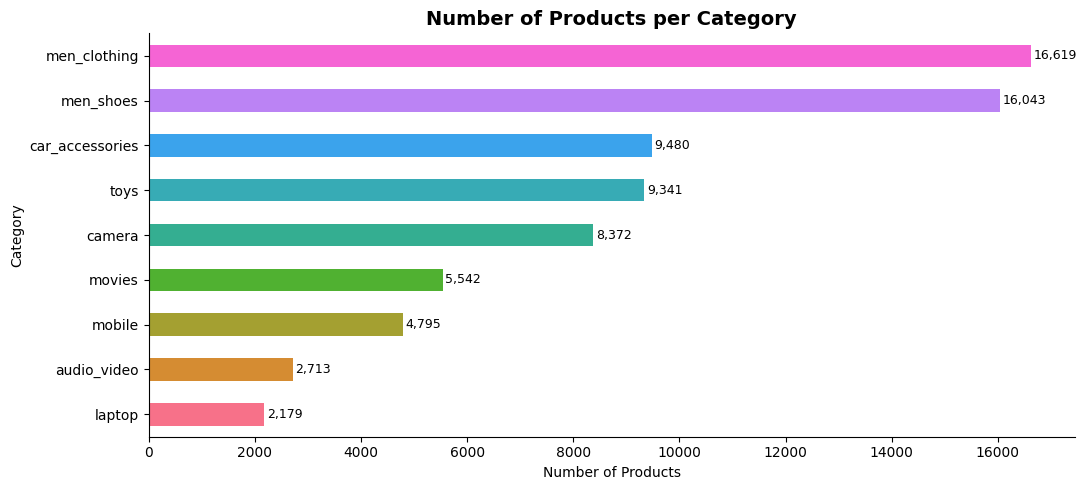

📊 Chart 1 saved


In [31]:
# CHART 1 — Bar Chart: Number of Products per Category
fig, ax = plt.subplots(figsize=(11, 5))
cat_counts.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('husl', len(cat_counts)))
ax.set_title('Number of Products per Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Products')
ax.set_ylabel('Category')
for bar in ax.patches:
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart1_products_per_category.png', dpi=150)
plt.show()


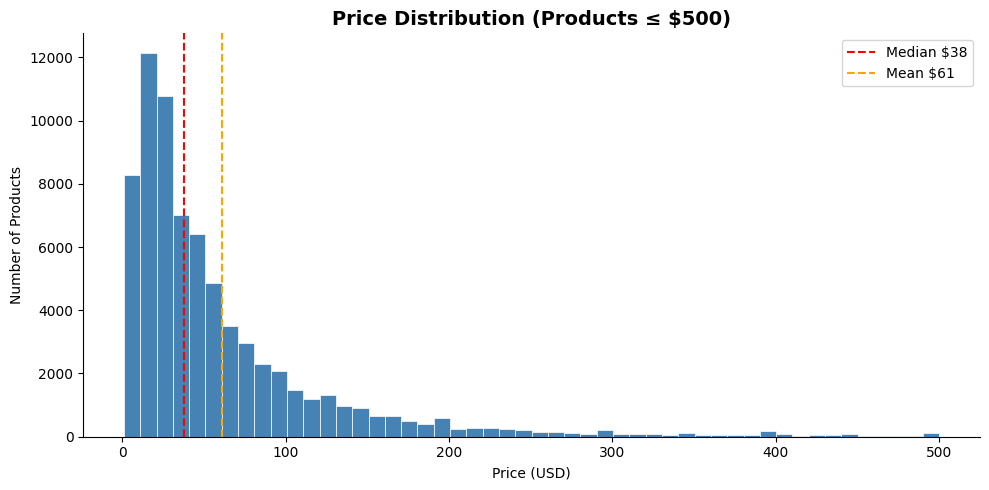

📊 Chart 2 saved


In [32]:
# CHART 2 — Histogram: Price Distribution (capped at $500 for readability)

fig, ax = plt.subplots(figsize=(10, 5))
price_cap = df[df['price'] <= 500]['price']
ax.hist(price_cap, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(price_cap.median(), color='red',    linestyle='--', label=f"Median ${price_cap.median():.0f}")
ax.axvline(price_cap.mean(),   color='orange', linestyle='--', label=f"Mean ${price_cap.mean():.0f}")
ax.set_title('Price Distribution (Products ≤ $500)', fontsize=14, fontweight='bold')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Number of Products')
ax.legend()
plt.tight_layout()
plt.savefig('chart2_price_distribution.png', dpi=150)
plt.show()


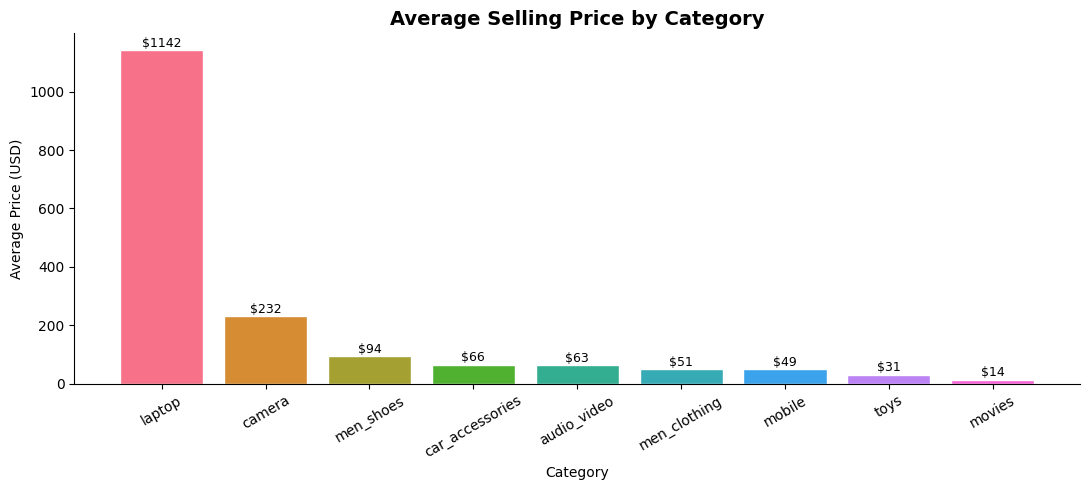

📊 Chart 3 saved


In [33]:
# CHART 3 — Bar Chart: Average Price per Category

fig, ax = plt.subplots(figsize=(11, 5))
avg_price = cat_summary['avg_price'].sort_values(ascending=False)
bars = ax.bar(avg_price.index, avg_price.values,
              color=sns.color_palette('husl', len(avg_price)), edgecolor='white')
ax.set_title('Average Selling Price by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Average Price (USD)')
ax.tick_params(axis='x', rotation=30)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"${bar.get_height():.0f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('chart3_avg_price_per_category.png', dpi=150)
plt.show()


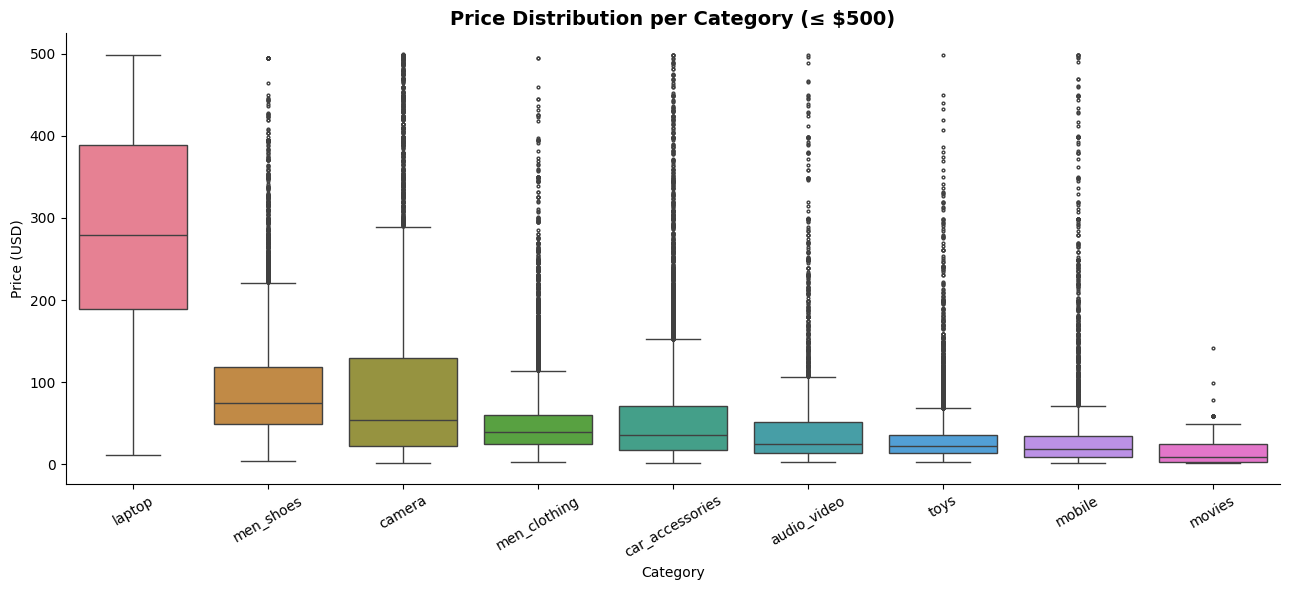

📊 Chart 4 saved


In [34]:
# CHART 4 — Boxplot: Price Distribution per Category (capped at $500)

fig, ax = plt.subplots(figsize=(13, 6))
capped = df[df['price'] <= 500]
order  = capped.groupby('category')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=capped, x='category', y='price', order=order,
            palette='husl', ax=ax, flierprops=dict(markersize=2))
ax.set_title('Price Distribution per Category (≤ $500)', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Price (USD)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('chart4_boxplot_price_category.png', dpi=150)
plt.show()


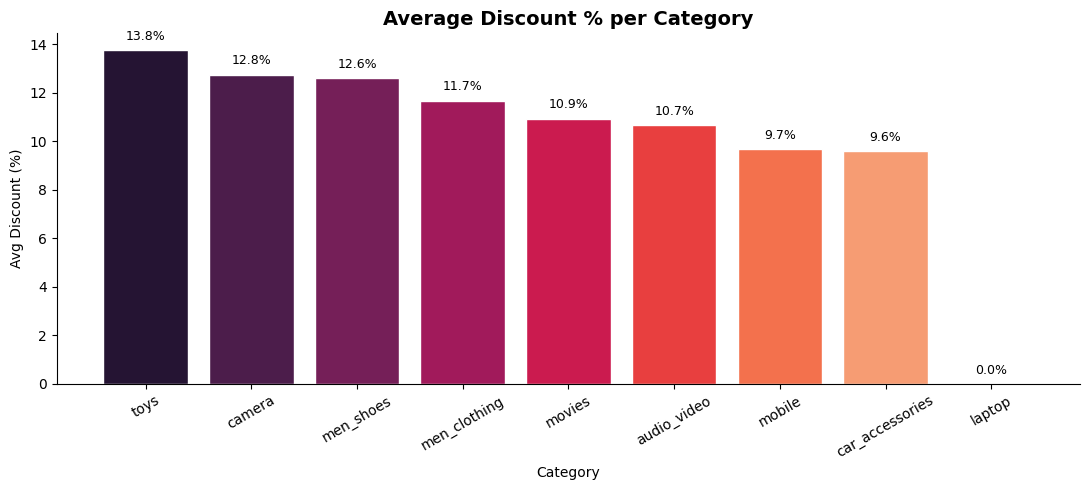

📊 Chart 5 saved


In [35]:
# CHART 5 — Bar Chart: Average Discount % per Category
fig, ax = plt.subplots(figsize=(11, 5))
disc_sorted = cat_summary['avg_discount_pct'].sort_values(ascending=False)
bars = ax.bar(disc_sorted.index, disc_sorted.values,
              color=sns.color_palette('rocket', len(disc_sorted)), edgecolor='white')
ax.set_title('Average Discount % per Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Avg Discount (%)')
ax.tick_params(axis='x', rotation=30)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('chart5_avg_discount_category.png', dpi=150)
plt.show()

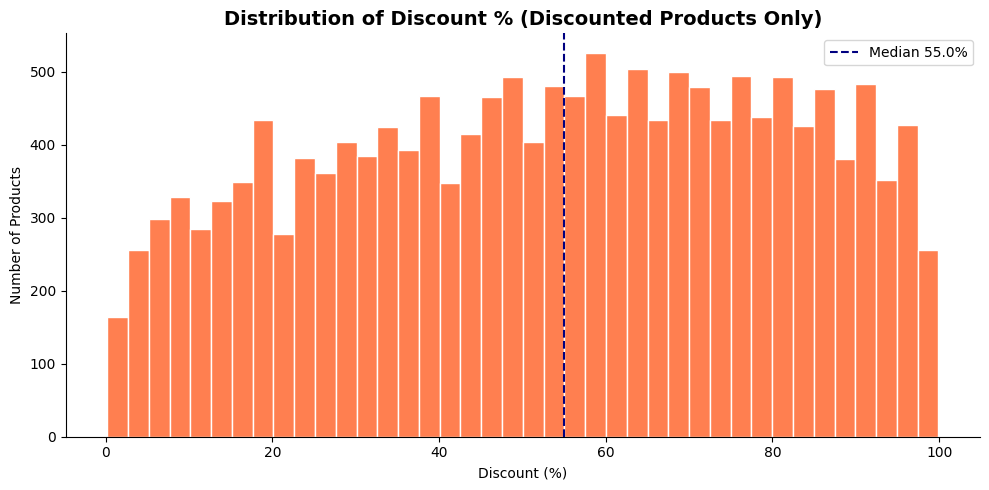

📊 Chart 6 saved


In [36]:
# CHART 6 — Histogram: Discount % Distribution

fig, ax = plt.subplots(figsize=(10, 5))
disc_data = df[df['discount_pct'] > 0]['discount_pct']
ax.hist(disc_data, bins=40, color='coral', edgecolor='white')
ax.set_title('Distribution of Discount % (Discounted Products Only)', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount (%)')
ax.set_ylabel('Number of Products')
ax.axvline(disc_data.median(), color='navy', linestyle='--',
           label=f"Median {disc_data.median():.1f}%")
ax.legend()
plt.tight_layout()
plt.savefig('chart6_discount_distribution.png', dpi=150)
plt.show()


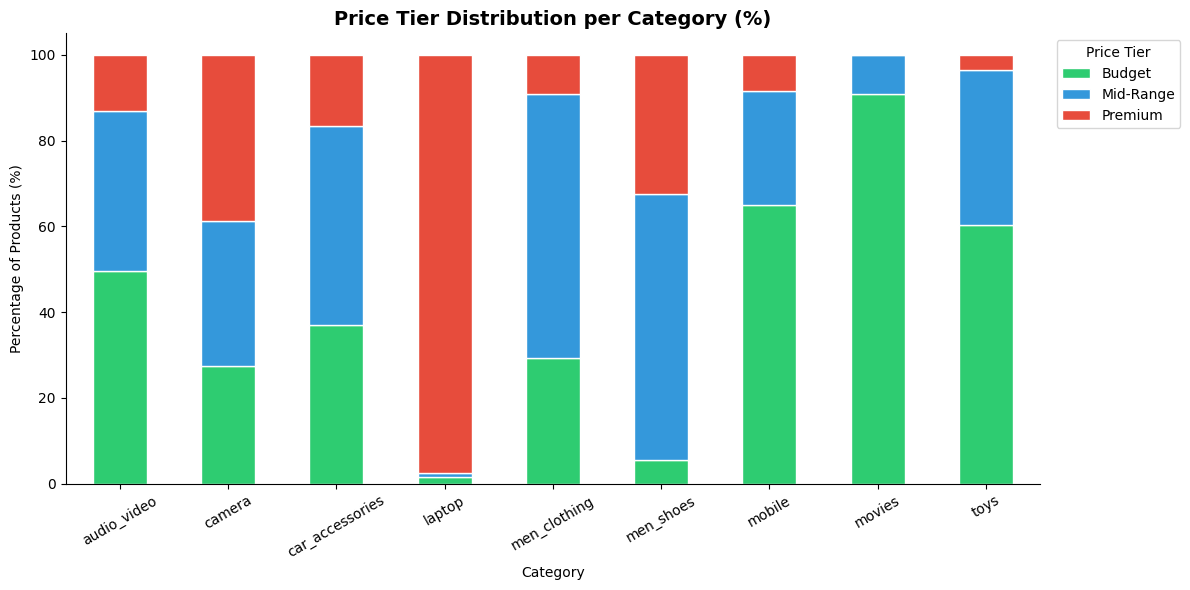

📊 Chart 7 saved


In [37]:
# CHART 7 — Stacked Bar: Price Tier per Category

tier_pct = tier_cat.div(tier_cat.sum(axis=1), axis=0) * 100
tier_order = ['Budget', 'Mid-Range', 'Premium']
tier_pct = tier_pct[[c for c in tier_order if c in tier_pct.columns]]
fig, ax = plt.subplots(figsize=(12, 6))
tier_pct.plot(kind='bar', stacked=True, ax=ax,
              color=['#2ecc71','#3498db','#e74c3c'], edgecolor='white')
ax.set_title('Price Tier Distribution per Category (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Percentage of Products (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Price Tier', bbox_to_anchor=(1.01,1))
plt.tight_layout()
plt.savefig('chart7_price_tier_stacked.png', dpi=150)
plt.show()


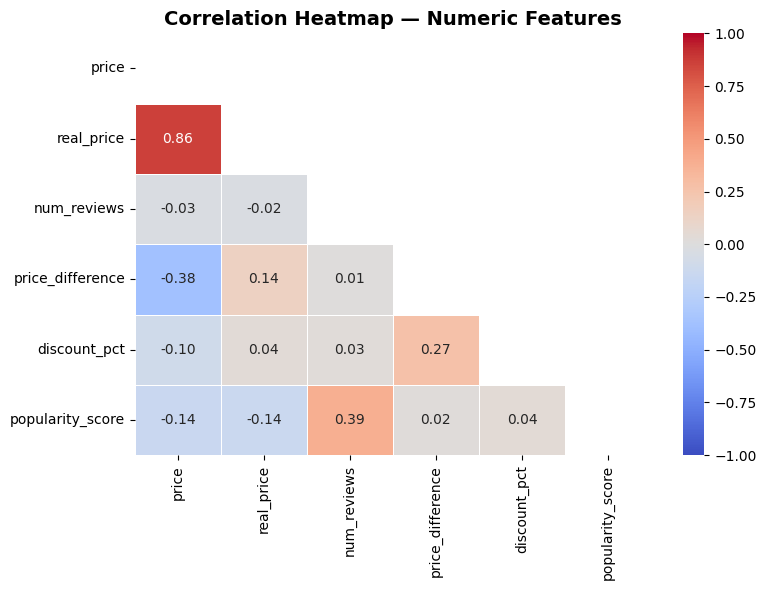

📊 Chart 8 saved


In [38]:
# CHART 8 — Correlation Heatmap

fig, ax = plt.subplots(figsize=(8, 6))
num_cols = ['price','real_price','num_reviews','price_difference','discount_pct','popularity_score']
corr_mat = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_correlation_heatmap.png', dpi=150)
plt.show()


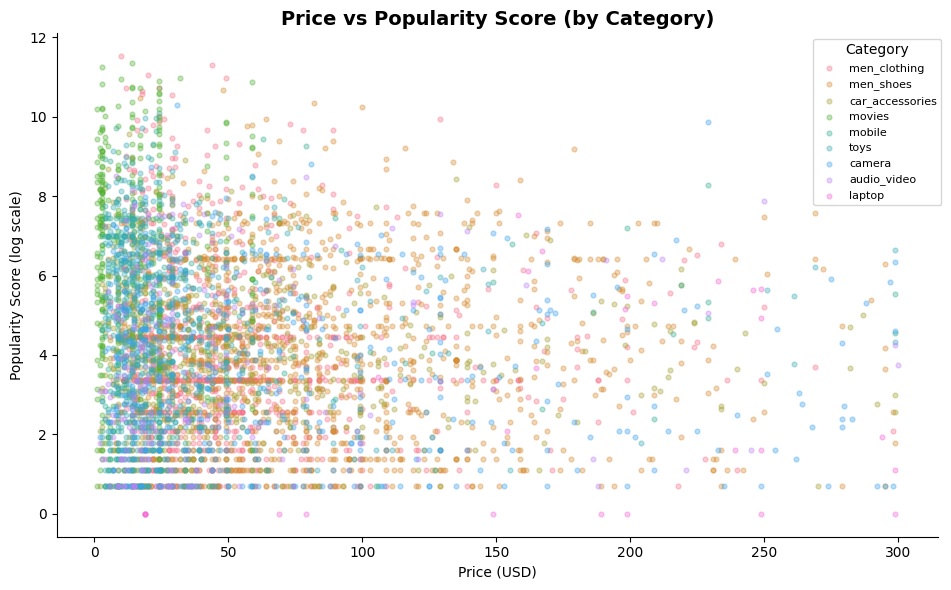

📊 Chart 9 saved


In [39]:
# CHART 9 — Scatter: Price vs Popularity Score (coloured by category)

fig, ax = plt.subplots(figsize=(11, 6))
sample = df[df['price'] <= 300].sample(min(5000, len(df)), random_state=42)
cats   = sample['category'].unique()
colors = sns.color_palette('husl', len(cats))
for cat, col in zip(cats, colors):
    sub = sample[sample['category'] == cat]
    ax.scatter(sub['price'], sub['popularity_score'], alpha=0.35, s=12, color=col, label=cat)
ax.set_title('Price vs Popularity Score (by Category)', fontsize=14, fontweight='bold')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Popularity Score (log scale)')
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.savefig('chart9_price_vs_popularity.png', dpi=150)
plt.show()

---
## Step 7 — Save Cleaned Dataset

In [41]:
df.to_csv('cleaned_amazon_dataset.csv', index=False)
print(f"   Final shape: {df.shape}")
print(f"   Columns    : {list(df.columns)}")

   Final shape: (75084, 14)
   Columns    : ['product_description', 'price', 'real_price', 'num_reviews', 'free_days', 'shipment', 'delivery_date', 'category', 'sells_past_month', 'price_difference', 'discount_pct', 'popularity_score', 'price_tier', 'has_discount']


---
## Step 8 — Key Insights & Business Implications

### 📌 Key Findings

| # | Finding |
|---|---|

| 1 | **Men's Clothing & Men's Shoes** have the highest product count, indicating a very competitive marketplace. |

| 2 | **Laptops and Mobiles** have the highest average selling prices, as expected for electronics. |

| 3 | **Movies and Audio/Video** products typically fall in the Budget tier (under $25). |

| 4 | A large percentage of products carry a discount — real_price vs price difference is significant in Camera and Car Accessories categories. |

| 5 | **Popularity score is not strongly correlated with price** — cheap products can still attract massive reviews. |

| 6 | **Discount % is highest in Camera and Car Accessories** — sellers use aggressive pricing to capture volume. |

| 7 | Most products are priced under $100 — the distribution is heavily right-skewed with a few luxury outliers. |

### 💼 Business Implications

1. **Inventory Strategy** — Stock Budget and Mid-Range products across clothing and shoes since they dominate volume.
2. **Discount Campaigns** — Camera and Car Accessories offer the most discount headroom — good candidates for flash sales.
3. **Pricing Intelligence** — Premium electronics (laptops/mobiles) should be monitored closely as pricing pressure is high.
4. **Review as a Trust Signal** — Products with high reviews (high popularity_score) regardless of price tend to sell more; sellers should focus on garnering early reviews.
5. **Category Expansion** — Movies is a low-competition, low-price category with potential for bundling or cross-selling.

